# Análise de Componentes Principais (PCA) e Redução de Dimensionalidade

Este arquivo consolida a etapa final de modelagem estatística multivariada sobre o ecossistema do ESAVI. O meu objetivo aqui é aplicar o algoritmo de PCA para reduzir o espaço multidimensional que estruturei nos scripts anteriores.

### Objetivos da minha análise nesta etapa:
1. **Redução Dimensional:** Projetar o dataset em espaços menores de 2 e 3 componentes principais.
2. **Avaliação de Variância:** Identificar, por meio do gráfico de Variância Explicada (*Scree Plot*), o quanto de informação original eu consegui reter nesses novos eixos.
3. **Visualização Geométrica:** Construir um Scatter Plot 2D dos dois primeiros componentes para mapear visualmente a dispersão dos pacientes e identificar possíveis agrupamentos ou padrões espaciais.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Configuro o comportamento estético padrão dos meus gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Carrego a matriz de dados que eu já havia padronizado via Z-Score no pipeline anterior
print("Carregando o dataset preparado para o PCA...")
df_pca_input = pd.read_csv('dataset_ESAVI_preparado_para_PCA.csv')

# Exibo a confirmação dimensional para garantir a integridade da matriz
print(f"Matriz carregada com sucesso. Dimensões: {df_pca_input.shape[0]} linhas por {df_pca_input.shape[1]} colunas.")

Carregando o dataset preparado para o PCA...
Matriz carregada com sucesso. Dimensões: 386 linhas por 23 colunas.


## 1. Execução do Algoritmo de PCA (2 e 3 Componentes)

Aqui eu instancio e aplico o modelo matemático de PCA em duas frentes independentes. Para evitar erros de leitura de arquivos em disco mais à frente, eu isolo a coluna `Atendimento_Medico` antes de passar os dados para o algoritmo, garantindo que o PCA seja calculado estritamente sobre as variáveis preditoras e que eu mantenha o rótulo original na memória.

In [6]:
# Eu separo a coluna de desfecho médico para que ela não entre no cálculo matemático do PCA
if 'Atendimento_Medico' in df_pca_input.columns:
    coluna_medico_backup = df_pca_input['Atendimento_Medico'].values
    # Discrimino os eixos removendo o desfecho para a decomposição pura
    df_dados_puros = df_pca_input.drop(columns=['Atendimento_Medico'])
else:
    df_dados_puros = df_pca_input.copy()
    coluna_medico_backup = None

# A) Eu executo o PCA limitando a estrutura a 2 componentes principais
pca_2d = PCA(n_components=2)
dados_pca_2d = pca_2d.fit_transform(df_dados_puros)

# B) Eu executo o PCA estendendo a estrutura para 3 componentes principais
pca_3d = PCA(n_components=3)
dados_pca_3d = pca_3d.fit_transform(df_dados_puros)

print("=== DECOMPOSIÇÃO CONCLUÍDA ===")
print(f"PCA 2D: {dados_pca_2d.shape[1]} eixos criados.")
print(f"PCA 3D: {dados_pca_3d.shape[1]} eixos criados.")

=== DECOMPOSIÇÃO CONCLUÍDA ===
PCA 2D: 2 eixos criados.
PCA 3D: 3 eixos criados.


## 2. Análise da Variância Explicada Acumulada

Nesta etapa, eu analiso a qualidade da minha redução dimensional. Eu preciso quantificar o percentual de variabilidade (informação) dos dados originais que sobreviveu à projeção nos novos componentes artificiais. Para isso, ploto o gráfico de barras combinado com a linha de ganho acumulado.

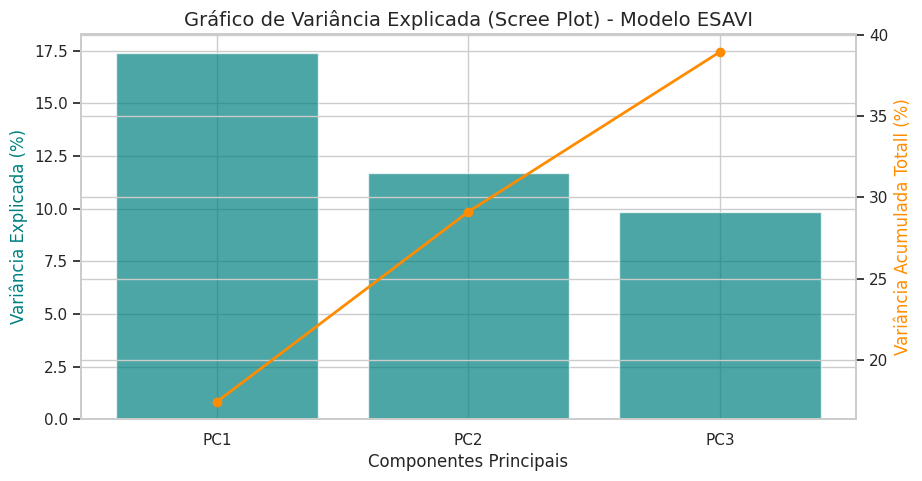

=== DIAGNÓSTICO MATEMÁTICO DA VARIÂNCIA ===
PC1 explica individualmente: 17.41% da informação original.
PC2 explica individualmente: 11.71% da informação original.
PC3 explica individualmente: 9.85% da informação original.
O modelo final com 3 componentes retém um total acumulado de: 38.97% de variância.


In [7]:
# Eu extraio os percentuais de variância individual de cada componente do modelo de 3 eixos
variancia_individual = pca_3d.explained_variance_ratio_ * 100
variancia_acumulada = np.cumsum(variancia_individual)

# Configuro o meu gráfico para exibir a perda e o ganho de informação por componente
fig, ax1 = plt.subplots(figsize=(10, 5))

# Ploto as barras mostrando a variância individual retida por cada eixo
ax1.bar(range(1, 4), variancia_individual, alpha=0.7, color='teal', label='Variância Individual')
ax1.set_ylabel('Variância Explicada (%)', color='teal')
ax1.set_xlabel('Componentes Principais')
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(['PC1', 'PC2', 'PC3'])

# Crio um segundo eixo y compartilhado para plotar a curva acumulada
ax2 = ax1.twinx()
ax2.plot(range(1, 4), variancia_acumulada, color='darkorange', marker='o', linewidth=2, label='Variância Acumulada')
ax2.set_ylabel('Variância Acumulada Totall (%)', color='darkorange')

plt.title('Gráfico de Variância Explicada (Scree Plot) - Modelo ESAVI', fontsize=14)
plt.show()

# Exibo os valores numéricos exatos no console para documentar no meu relatório
print("=== DIAGNÓSTICO MATEMÁTICO DA VARIÂNCIA ===")
for i, var in enumerate(variancia_individual):
    print(f"PC{i+1} explica individualmente: {var:.2f}% da informação original.")
print(f"O modelo final com 3 componentes retém um total acumulado de: {variancia_acumulada[-1]:.2f}% de variância.")

## 3. Construção do Scatter Plot 2D no Espaço de Componentes

Para dar interpretação física ao meu modelo abstrato, construo um Scatter Plot utilizando as coordenadas dos dois primeiros componentes principais (`PC1` e `PC2`). 

Eu trago o vetor de atendimento médico que salvei na memória na etapa anterior para atuar como legenda de cores (`hue`). Isso me permite avaliar visualmente se o PCA conseguiu separar geometricamente os pacientes que precisaram de intervenção médica daqueles que não precisaram, sem depender de leituras externas de outros arquivos.

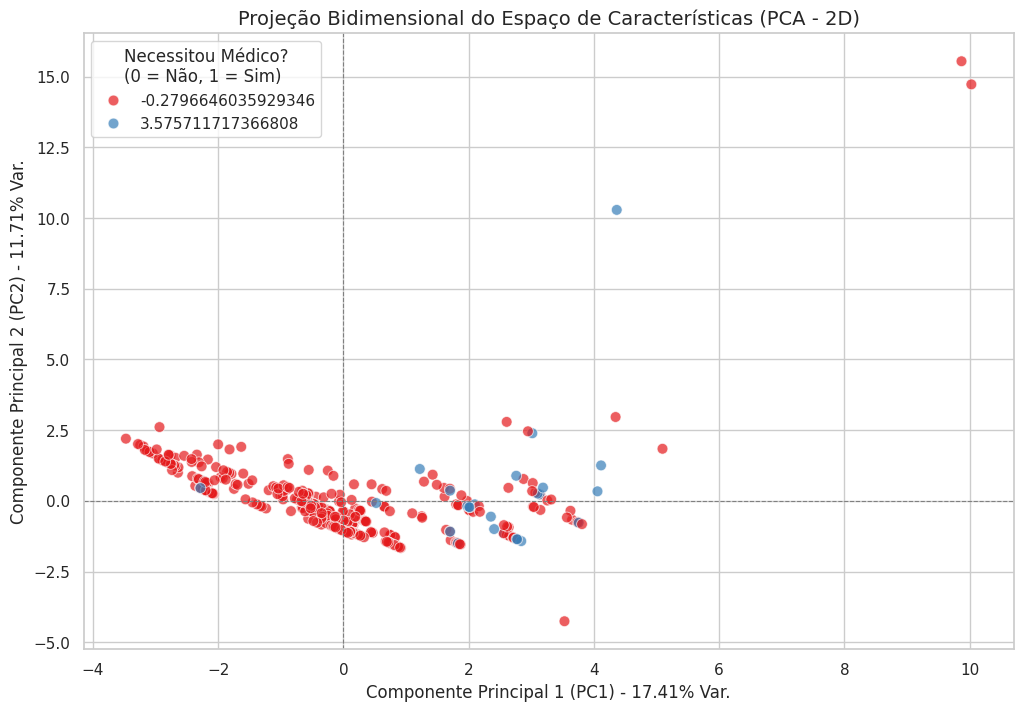


ETAPA DE REDUÇÃO DIMENSIONAL E PCA CONCLUÍDA


In [8]:
# Crio o meu DataFrame temporário para organizar as coordenadas que o PCA gerou
df_plot_2d = pd.DataFrame(dados_pca_2d, columns=['PC1', 'PC2'])

# Resgato o vetor de backup que deixei guardado na memória interna do script
if coluna_medico_backup is not None:
    df_plot_2d['Atendimento_Medico'] = coluna_medico_backup
else:
    df_plot_2d['Atendimento_Medico'] = 0  # Fallback caso a coluna não estivesse no arquivo

# Ploto a dispersão dos dados no novo plano cartesiano ortogonal gerado pelo PCA
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_plot_2d, 
    x='PC1', 
    y='PC2', 
    hue='Atendimento_Medico', 
    palette='Set1', 
    alpha=0.7, 
    s=60
)

# Adiciono marcações estéticas e linhas guias nos eixos zero para marcar o centro de massa dos dados
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.title('Projeção Bidimensional do Espaço de Características (PCA - 2D)', fontsize=14)
plt.xlabel(f'Componente Principal 1 (PC1) - {variancia_individual[0]:.2f}% Var.')
plt.ylabel(f'Componente Principal 2 (PC2) - {variancia_individual[1]:.2f}% Var.')
plt.legend(title='Necessitou Médico?\n(0 = Não, 1 = Sim)')
plt.show()

print("\n" + "="*60)
print("ETAPA DE REDUÇÃO DIMENSIONAL E PCA CONCLUÍDA")
print("="*60)